<a href="https://colab.research.google.com/github/Gabriel-git24/cassava_leaf_disease_classification/blob/main/Copy_of_Capstone_project_1_v10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import tensorflow as tf

class MacroF1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = [self.add_weight(name=f'tp_{c}', initializer='zeros') for c in range(num_classes)]
        self.fp = [self.add_weight(name=f'fp_{c}', initializer='zeros') for c in range(num_classes)]
        self.fn = [self.add_weight(name=f'fn_{c}', initializer='zeros') for c in range(num_classes)]

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(tf.argmax(y_pred, axis=1), tf.int32)
        y_true = tf.cast(tf.argmax(y_true, axis=1), tf.int32)
        for c in range(self.num_classes):
            c_tensor = tf.constant(c, dtype=tf.int32)
            tp = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_pred, c_tensor), tf.equal(y_true, c_tensor)), tf.float32))
            fp = tf.reduce_sum(tf.cast(tf.logical_and(tf.equal(y_pred, c_tensor), tf.not_equal(y_true, c_tensor)), tf.float32))
            fn = tf.reduce_sum(tf.cast(tf.logical_and(tf.not_equal(y_pred, c_tensor), tf.equal(y_true, c_tensor)), tf.float32))
            self.tp[c].assign_add(tp)
            self.fp[c].assign_add(fp)
            self.fn[c].assign_add(fn)

    def result(self):
        f1_scores = []
        for c in range(self.num_classes):
            precision = self.tp[c] / (self.tp[c] + self.fp[c] + 1e-7)
            recall = self.tp[c] / (self.tp[c] + self.fn[c] + 1e-7)
            f1 = 2 * precision * recall / (precision + recall + 1e-7)
            f1_scores.append(f1)
        return tf.reduce_mean(tf.stack(f1_scores))

    def reset_state(self):
        for c in range(self.num_classes):
            self.tp[c].assign(0.)
            self.fp[c].assign(0.)
            self.fn[c].assign(0.)

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.utils import class_weight
import numpy as np
import pathlib

data_dir = "/content/drive/MyDrive/Capstone Project/archive (5)/split_dataset"
image_size = (224, 224)
batch_size = 32
num_epochs = 100
class_names = [
    "Cassava___bacterial_blight",
    "Cassava___brown_streak_disease",
    "Cassava___green_mottle",
    "Cassava___mosaic_disease",
    "Cassava___healthy"
]
num_classes = len(class_names)

mixed_precision.set_global_policy('mixed_float16')

# ── Preprocessing functions ──────────────────────────────────────────────────

def suppress_background_mild(image, threshold=0.2, softness=1.5):
    image = tf.cast(image, tf.float32)
    r, g, b = image[..., 0], image[..., 1], image[..., 2]
    total = r + g + b + 1e-6
    exg = 2.0 * g - r - b
    exg_min = tf.reduce_min(exg, axis=[-2, -1], keepdims=True)
    exg_max = tf.reduce_max(exg, axis=[-2, -1], keepdims=True)
    exg_norm = (exg - exg_min) / (exg_max - exg_min + 1e-6)
    green_ratio = g / total
    brown_score = tf.nn.relu(r - g) + tf.nn.relu(g - b)
    brown_min = tf.reduce_min(brown_score, axis=[-2, -1], keepdims=True)
    brown_max = tf.reduce_max(brown_score, axis=[-2, -1], keepdims=True)
    brown_norm = (brown_score - brown_min) / (brown_max - brown_min + 1e-6)
    combined = 0.5 * exg_norm + 0.3 * green_ratio - 0.15 * brown_norm
    combined_min = tf.reduce_min(combined, axis=[-2, -1], keepdims=True)
    combined_max = tf.reduce_max(combined, axis=[-2, -1], keepdims=True)
    combined_norm = (combined - combined_min) / (combined_max - combined_min + 1e-6)
    mask = 0.4 + 0.6 * tf.sigmoid(softness * (combined_norm - threshold))
    mask = tf.expand_dims(mask, axis=-1)
    mask = tf.repeat(mask, 3, axis=-1)
    return image * mask

def denoise(image):
    image = tf.cast(image, tf.float32)
    kernel = tf.constant([[1,2,1],[2,4,2],[1,2,1]], dtype=tf.float32) / 16.0
    kernel = tf.reshape(kernel, [3, 3, 1, 1])
    kernel = tf.repeat(kernel, 3, axis=2)
    needs_expand = (len(image.shape) == 3)
    if needs_expand:
        image = tf.expand_dims(image, 0)
    smoothed = tf.nn.depthwise_conv2d(image, kernel, strides=[1,1,1,1], padding='SAME')
    if needs_expand:
        smoothed = tf.squeeze(smoothed, 0)
    return smoothed

def sharpen(image, strength=0.6):
    image = tf.cast(image, tf.float32)
    blurred = denoise(image)
    sharpened = image + strength * (image - blurred)
    return tf.clip_by_value(sharpened, 0.0, 255.0)

def adjust_contrast(image, factor=1.3):
    image = tf.cast(image, tf.float32)
    mean = tf.reduce_mean(image, axis=[-3, -2, -1], keepdims=True)
    image = (image - mean) * factor + mean
    return tf.clip_by_value(image, 0.0, 255.0)

def color_normalize(image):
    image = tf.cast(image, tf.float32)
    mean = tf.reduce_mean(image, axis=[-3, -2, -1], keepdims=True)
    variance = tf.math.reduce_variance(image, axis=[-3, -2, -1], keepdims=True)
    image = (image - mean) / (tf.sqrt(variance) + 1e-6)
    image = image * 64.0 + 128.0
    return tf.clip_by_value(image, 0.0, 255.0)

# def full_preprocess(image):
#     image = tf.cast(image, tf.float32)
#     image = suppress_background_mild(image)  # 1. mild background dimming
#     image = denoise(image)                   # 2. smooth sensor noise
#     image = sharpen(image)                   # 3. enhance edges
#     image = adjust_contrast(image)           # 4. boost lesion visibility
#     image = color_normalize(image)           # 5. normalize lighting
#     return preprocess_input(image)           # 6. ResNet scaling

def full_preprocess(image):
    return preprocess_input(tf.cast(image, tf.float32))
# ── Augmentation functions ───────────────────────────────────────────────────

def augment(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return image

def augment_heavy(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)
    image = tf.image.random_hue(image, max_delta=0.1)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)
    return image

# ── Dataset loading ──────────────────────────────────────────────────────────

train_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

val_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/val",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)


class_counts = [760, 1532, 1670, 9210, 1803]
target = max(class_counts)

train_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/train",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_generator = tf.keras.utils.image_dataset_from_directory(
    f"{data_dir}/test",
    image_size=image_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

# ── Pipeline ─────────────────────────────────────────────────────────────────

AUTOTUNE = tf.data.AUTOTUNE

train_generator = train_generator.map(
    lambda x, y: (full_preprocess(x), y), num_parallel_calls=AUTOTUNE
)
train_generator = train_generator.map(
    lambda x, y: (augment(x), y), num_parallel_calls=AUTOTUNE
)
train_generator = train_generator.prefetch(AUTOTUNE)

val_generator = val_generator.map(
    lambda x, y: (full_preprocess(x), y), num_parallel_calls=AUTOTUNE
)
val_generator = val_generator.prefetch(AUTOTUNE)

test_generator = test_generator.map(
    lambda x, y: (full_preprocess(x), y), num_parallel_calls=AUTOTUNE
)
test_generator = test_generator.prefetch(AUTOTUNE)

Found 14975 files belonging to 5 classes.
Found 3206 files belonging to 5 classes.
Found 14975 files belonging to 5 classes.
Found 3215 files belonging to 5 classes.


In [4]:
import os

train_dir = f"{data_dir}/train"
class_names_sorted = sorted(os.listdir(train_dir))

print("=== Class Distribution ===")
total = 0
counts = {}
for name in class_names_sorted:
    count = len(os.listdir(os.path.join(train_dir, name)))
    counts[name] = count
    total += count
    print(f"  {name}: {count} images")

print(f"\nTotal: {total}")
print(f"Largest/Smallest ratio: {max(counts.values())/min(counts.values()):.1f}x")

=== Class Distribution ===
  Cassava___bacterial_blight: 760 images
  Cassava___brown_streak_disease: 1532 images
  Cassava___green_mottle: 1670 images
  Cassava___healthy: 1803 images
  Cassava___mosaic_disease: 9210 images

Total: 14975
Largest/Smallest ratio: 12.1x


In [5]:
# import random

# # pick one image per class for a targeted sanity check
# class_samples = {name: None for name in class_names}

# for images, labels in train_generator:
#     for img, label in zip(images, labels):
#         class_idx = tf.argmax(label).numpy()
#         class_name = class_names[class_idx]
#         if class_samples[class_name] is None:
#             class_samples[class_name] = img
#     if all(v is not None for v in class_samples.values()):
#         break

# fig, axes = plt.subplots(num_classes, 6, figsize=(20, 4 * num_classes))
# col_titles = ["Original", "BG Suppressed", "+ Denoise", "+ Sharpen", "+ Contrast", "Final"]

# for row, (class_name, img) in enumerate(class_samples.items()):
#     img_f = tf.cast(img, tf.float32)

#     stage1 = suppress_background_mild(img_f)
#     stage2 = denoise(stage1)
#     stage3 = sharpen(stage2)
#     stage4 = adjust_contrast(stage3)
#     stage5 = color_normalize(stage4)

#     stages = [img_f, stage1, stage2, stage3, stage4, stage5]

#     for col, (stage, title) in enumerate(zip(stages, col_titles)):
#         ax = axes[row][col]

#         # color_normalize output is not in [0,255] so scale it for display
#         display = stage.numpy()
#         if col == 5:
#             display = (display - display.min()) / (display.max() - display.min() + 1e-6)
#             display = (display * 255).astype("uint8")
#         else:
#             display = tf.clip_by_value(stage, 0, 255).numpy().astype("uint8")

#         ax.imshow(display)
#         if row == 0:
#             ax.set_title(title, fontsize=11, fontweight='bold')
#         if col == 0:
#             ax.set_ylabel(class_name.replace("Cassava___", ""), fontsize=9, rotation=90, labelpad=10)
#         ax.axis('off')

# plt.suptitle("Preprocessing Pipeline — One Sample Per Class", fontsize=14, fontweight='bold', y=1.01)
# plt.tight_layout()
# plt.show()

In [6]:
import os

train_dir = f"{data_dir}/train"

class_names = sorted(os.listdir(train_dir))

class_counts = np.array([
    len(os.listdir(os.path.join(train_dir, name)))
    for name in class_names
])

total = class_counts.sum()
weights = total / (num_classes * class_counts)
class_weights = dict(enumerate(weights))

print("Class counts:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_counts[i]} samples, weight: {class_weights[i]:.3f}")

Class counts:
  Cassava___bacterial_blight: 760 samples, weight: 3.941
  Cassava___brown_streak_disease: 1532 samples, weight: 1.955
  Cassava___green_mottle: 1670 samples, weight: 1.793
  Cassava___healthy: 1803 samples, weight: 1.661
  Cassava___mosaic_disease: 9210 samples, weight: 0.325


In [7]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.01):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        n_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true * (1 - self.label_smoothing) + self.label_smoothing / n_classes
        ce = -y_true * tf.math.log(y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = self.alpha * tf.pow(1.0 - pt, self.gamma)
        return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))

In [8]:
def build_model(input_shape=(224, 224, 3), num_classes=5, learning_rate=1e-4, trainable_backbone=False):

    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = trainable_backbone

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(3e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', MacroF1Score(num_classes=num_classes)]  # ← must be here
    )


    return model, base_model

In [9]:
model_path = "/content/drive/MyDrive/Capstone Project/models/resnet_v2.keras"

checkpoint = ModelCheckpoint(
    model_path,
    save_best_only=True,
    monitor="val_macro_f1",
    mode="max",
    verbose=1,
)

early_stopping = EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=10,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_macro_f1",
    mode="max",
    factor=0.2,
    patience=5,
    min_delta=0.001,
    verbose=1,
)

early_stopping_ft = EarlyStopping(
    monitor="val_macro_f1",
    mode="max",
    patience=3,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1,
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor="val_macro_f1",
    mode="max",
    factor=0.2,
    patience=3,
    min_delta=0.001,
    verbose=1,
)

model_path_ft = "/content/drive/MyDrive/Capstone Project/models/resnet_v2_ft.keras"

checkpoint_ft = ModelCheckpoint(
    model_path_ft,
    save_best_only=True,
    monitor="val_macro_f1",
    mode="max",
    verbose=1
)


# ─────────────────────────────────────────
# STAGE 1 — train classifier head only
# ─────────────────────────────────────────
print("\n===== STAGE 1: Training classifier head =====")
model, base_model = build_model(
    input_shape=(224, 224, 3),
    num_classes=num_classes,
    learning_rate=1e-4,
    trainable_backbone=False,
)

history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=35,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping, reduce_lr],
)


# ─────────────────────────────────────────
# STAGE 2 — fine-tune last 40 backbone layers
# ─────────────────────────────────────────
print("\n===== STAGE 2: Fine-tuning =====")

# Unfreeze fewer layers than before (40 instead of 80)
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

initial_learning_rate = 1e-6
warmup_epochs = 7
target_learning_rate = 3e-5

def warmup_schedule(epoch):
  if epoch < warmup_epochs:
    return initial_learning_rate + (target_learning_rate - initial_learning_rate) * (epoch/warmup_epochs)
  else:
    return target_learning_rate

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(warmup_schedule)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss=FocalLoss(gamma=2.0, alpha=0.25, label_smoothing=0.05),
    metrics=["accuracy", MacroF1Score(num_classes=num_classes)],
)

history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint_ft, early_stopping_ft, lr_scheduler],
)


===== STAGE 1: Training classifier head =====
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3176 - loss: 2.4378 - macro_f1: 0.2571
Epoch 1: val_macro_f1 improved from None to 0.48058, saving model to /content/drive/MyDrive/Capstone Project/models/resnet_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Capstone Project/models/resnet_v2.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 738s 2s/step - accuracy: 0.3728 - loss: 2.2174 - macro_f1: 0.3038 - val_accuracy: 0.6182 - val_loss: 1.3164 - val_macro_f1: 0.4806 - learning_rate: 1.0000e-04
Epoch 2/35
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4544 - loss: 1.8654 - macro_f1: 0.3723
Epoch 2: val_macro_f1 did not improve from 0.48058
468/468 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - accuracy: 0.4606 - loss: 1.8658 - macro_f1: 0.3757 - val_accuracy: 0.5137 - val_loss: 1.6049 - val_macro_f1: 0.4420 - learning_rate: 1.0000e-04
Epoch 3/35
468/468 ━━━━━━━━━━━━━━━

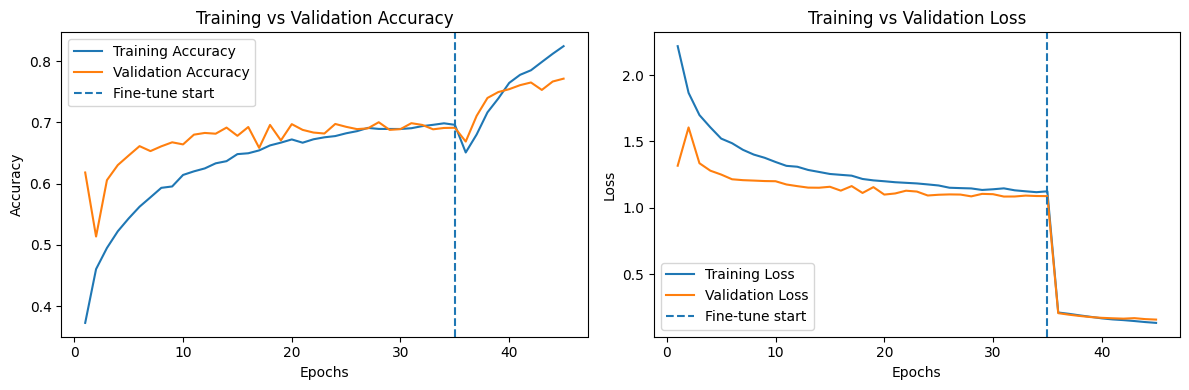

In [10]:
plt.figure(figsize=(12, 4))  # ADD THIS

acc = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']

loss = history_stage1.history['loss'] + history_stage2.history['loss']          # ADD .history
val_loss = history_stage1.history['val_loss'] + history_stage2.history['val_loss']  # ADD .history

epochs = range(1, len(acc) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_stage1.history['accuracy']), linestyle='--', label='Fine-tune start')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.axvline(x=len(history_stage1.history['loss']), linestyle='--', label='Fine-tune start')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

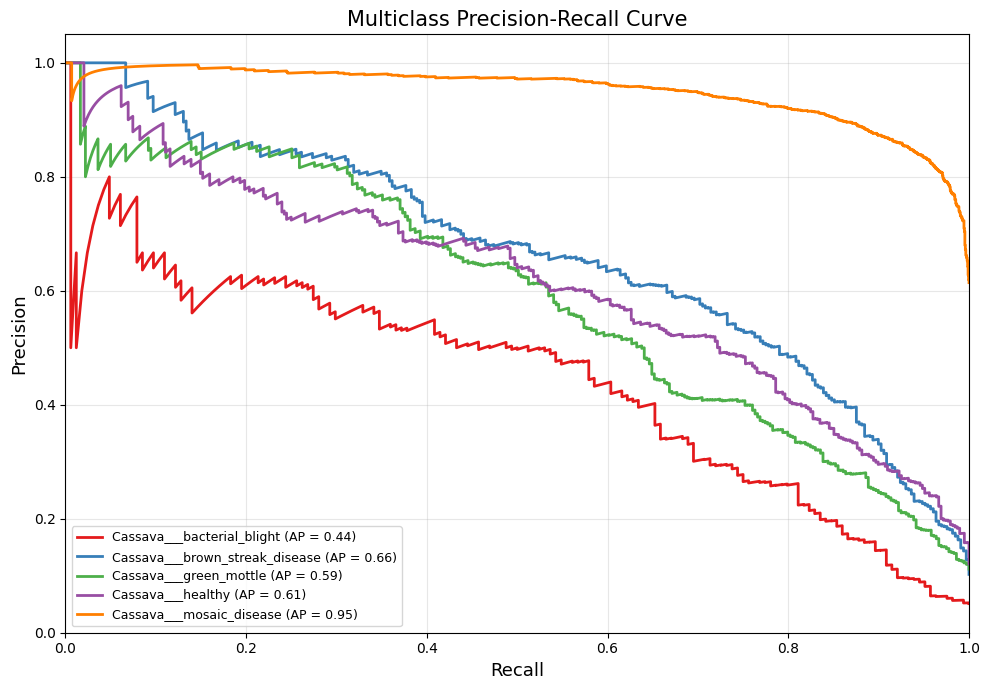

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_generator:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
    ap = average_precision_score(y_true[:, i], y_pred[:, i])
    ax.plot(recall, precision, color=color, lw=2, label=f"{class_name} (AP = {ap:.2f})")

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Multiclass Precision-Recall Curve", fontsize=15)
ax.legend(loc="lower left", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

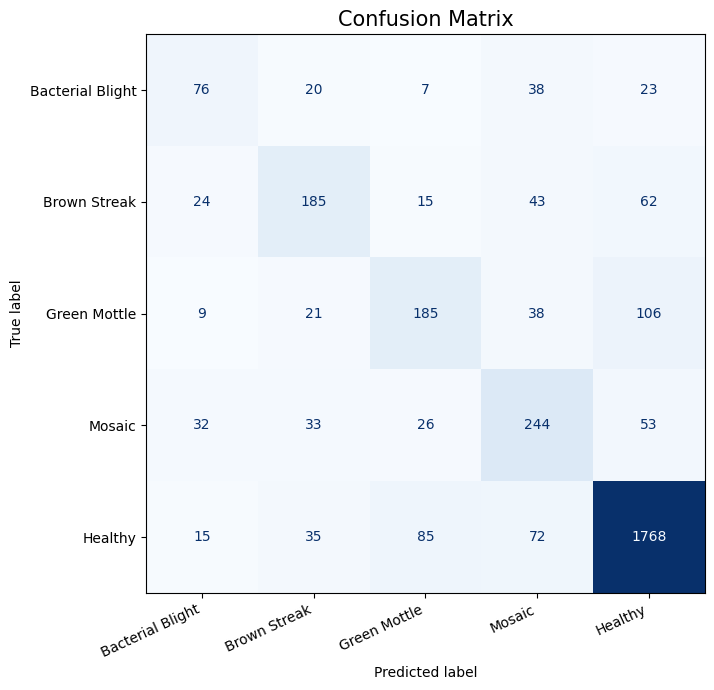


Per-class Accuracy:
  Bacterial Blight: 46.34%
  Brown Streak: 56.23%
  Green Mottle: 51.53%
  Mosaic: 62.89%
  Healthy: 89.52%


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reuse y_true and y_pred from above — just argmax them
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic",
    "Healthy"
]

cm = confusion_matrix(y_true_labels, y_pred_labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.xticks(rotation=25, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Confusion Matrix", fontsize=15)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class Accuracy:")
for i, name in enumerate(short_names):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {name}: {class_acc:.2%}")

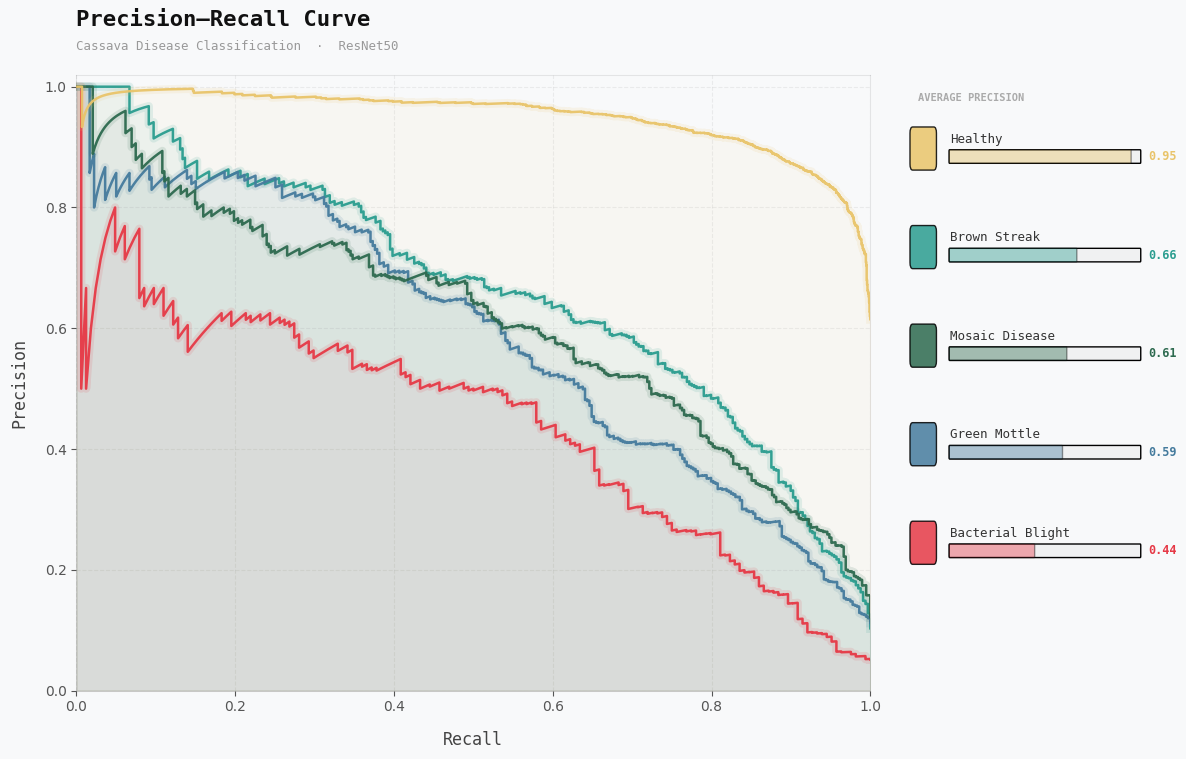

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(14, 8), facecolor='#F8F9FA')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

ax.set_facecolor('#F8F9FA')
ax_legend.set_facecolor('#F8F9FA')
ax_legend.axis('off')

ax.grid(True, color='#000000', alpha=0.06, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

colors = ['#E63946', '#2A9D8F', '#457B9D', '#2D6A4F', '#E9C46A']
short_names = ['Bacterial Blight', 'Brown Streak', 'Green Mottle', 'Mosaic Disease', 'Healthy']

legend_elements = []
for i, (name, color) in enumerate(zip(short_names, colors)):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred[:, i])
    ap = average_precision_score(y_true[:, i], y_pred[:, i])

    ax.plot(recall, precision, color=color, lw=6, alpha=0.12)
    ax.plot(recall, precision, color=color, lw=1.8, alpha=0.95, solid_capstyle='round')
    ax.fill_between(recall, precision, alpha=0.05, color=color)

    legend_elements.append((name, ap, color))

for spine in ax.spines.values():
    spine.set_color('#00000015')

ax.tick_params(colors='#555555', labelsize=10)
ax.set_xlabel('Recall', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_ylabel('Precision', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Change pad and loc on the title
ax.set_title('Precision–Recall Curve', color='#111111', fontsize=16,
             fontfamily='monospace', fontweight='bold', pad=35, loc='left')

# Move subtitle lower
ax.text(0, 1.04, 'Cassava Disease Classification  ·  ResNet50',
        transform=ax.transAxes, color='#999999', fontsize=9, fontfamily='monospace')

ax_legend.text(0.08, 0.97, 'AVERAGE PRECISION', color='#AAAAAA',
               fontsize=7.5, fontfamily='monospace', fontweight='bold',
               transform=ax_legend.transAxes, va='top')

legend_elements_sorted = sorted(legend_elements, key=lambda x: x[1], reverse=True)

for idx, (name, ap, color) in enumerate(legend_elements_sorted):
    y_pos = 0.88 - idx * 0.16

    rect = mpatches.FancyBboxPatch((0.06, y_pos - 0.025), 0.08, 0.05,
                                    boxstyle="round,pad=0.01",
                                    facecolor=color, alpha=0.85,
                                    transform=ax_legend.transAxes)
    ax_legend.add_patch(rect)

    ax_legend.text(0.2, y_pos + 0.015, name, color='#333333',
                   fontsize=9, fontfamily='monospace',
                   transform=ax_legend.transAxes, va='center')

    bar_x = 0.2
    bar_w = 0.72

    bar_bg = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w, 0.018,
                                      boxstyle="round,pad=0.002",
                                      facecolor='#00000008',
                                      transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_bg)

    bar_fill = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w * ap, 0.018,
                                        boxstyle="round,pad=0.002",
                                        facecolor=color, alpha=0.4,
                                        transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_fill)

    ax_legend.text(0.2 + bar_w + 0.03, y_pos - 0.013, f'{ap:.2f}',
                   color=color, fontsize=8.5, fontfamily='monospace',
                   fontweight='bold', transform=ax_legend.transAxes, va='center')

plt.savefig('pr_curve.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [14]:
from sklearn.metrics import classification_report

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic Disease",
    "Healthy"
]

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

print(classification_report(y_true_labels, y_pred_labels, target_names=short_names))

                  precision    recall  f1-score   support

Bacterial Blight       0.49      0.46      0.47       164
    Brown Streak       0.63      0.56      0.59       329
    Green Mottle       0.58      0.52      0.55       359
  Mosaic Disease       0.56      0.63      0.59       388
         Healthy       0.88      0.90      0.89      1975

        accuracy                           0.76      3215
       macro avg       0.63      0.61      0.62      3215
    weighted avg       0.76      0.76      0.76      3215



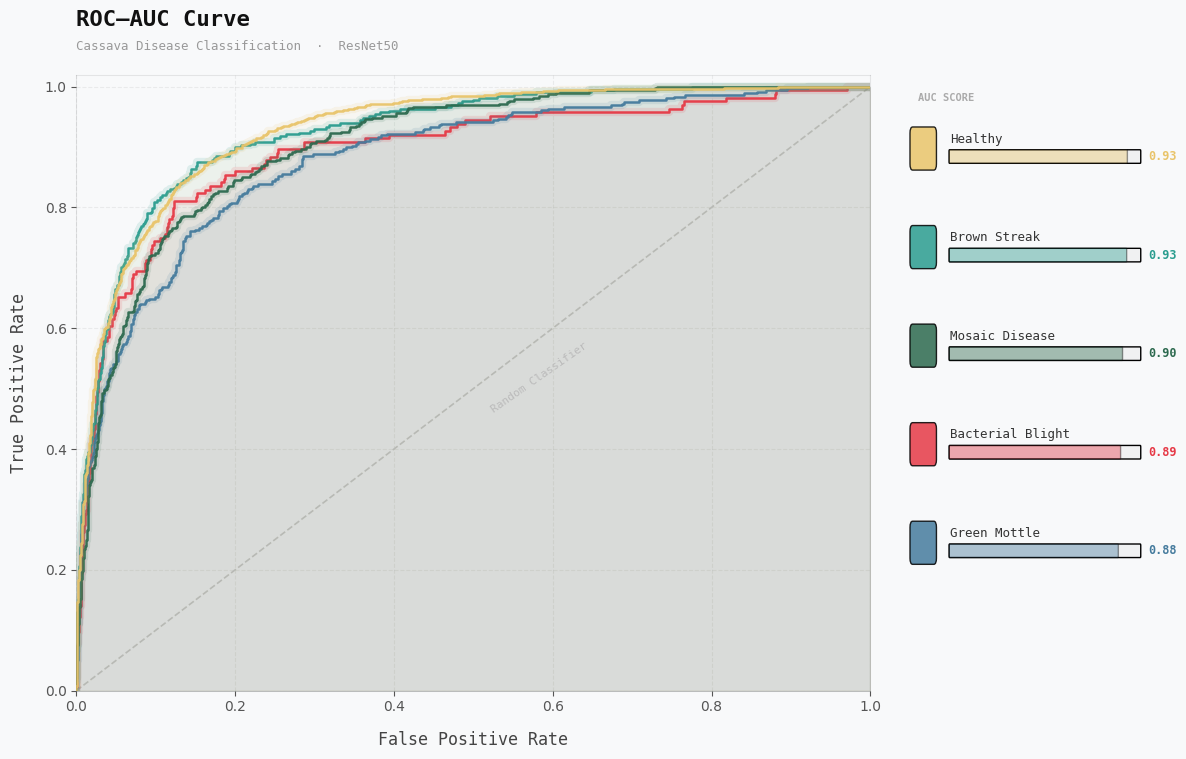

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(14, 8), facecolor='#F8F9FA')
gs = GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

ax.set_facecolor('#F8F9FA')
ax_legend.set_facecolor('#F8F9FA')
ax_legend.axis('off')

ax.grid(True, color='#000000', alpha=0.06, linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

# Random classifier baseline
ax.plot([0, 1], [0, 1], color='#CCCCCC', lw=1.2, linestyle='--', zorder=1)
ax.text(0.52, 0.46, 'Random Classifier', color='#BBBBBB', fontsize=8, fontfamily='monospace', rotation=35)

colors = ['#E63946', '#2A9D8F', '#457B9D', '#2D6A4F', '#E9C46A']
short_names = ['Bacterial Blight', 'Brown Streak', 'Green Mottle', 'Mosaic Disease', 'Healthy']

legend_elements = []
for i, (name, color) in enumerate(zip(short_names, colors)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=6, alpha=0.12)
    ax.plot(fpr, tpr, color=color, lw=1.8, alpha=0.95, solid_capstyle='round')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

    legend_elements.append((name, roc_auc, color))

for spine in ax.spines.values():
    spine.set_color('#00000015')

ax.tick_params(colors='#555555', labelsize=10)
ax.set_xlabel('False Positive Rate', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_ylabel('True Positive Rate', color='#444444', fontsize=12, labelpad=12, fontfamily='monospace')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

ax.set_title('ROC–AUC Curve', color='#111111', fontsize=16,
             fontfamily='monospace', fontweight='bold', pad=35, loc='left')
ax.text(0, 1.04, 'Cassava Disease Classification  ·  ResNet50',
        transform=ax.transAxes, color='#999999', fontsize=9, fontfamily='monospace')

ax_legend.text(0.08, 0.97, 'AUC SCORE', color='#AAAAAA',
               fontsize=7.5, fontfamily='monospace', fontweight='bold',
               transform=ax_legend.transAxes, va='top')

legend_elements_sorted = sorted(legend_elements, key=lambda x: x[1], reverse=True)

for idx, (name, roc_auc, color) in enumerate(legend_elements_sorted):
    y_pos = 0.88 - idx * 0.16

    rect = mpatches.FancyBboxPatch((0.06, y_pos - 0.025), 0.08, 0.05,
                                    boxstyle="round,pad=0.01",
                                    facecolor=color, alpha=0.85,
                                    transform=ax_legend.transAxes)
    ax_legend.add_patch(rect)

    ax_legend.text(0.2, y_pos + 0.015, name, color='#333333',
                   fontsize=9, fontfamily='monospace',
                   transform=ax_legend.transAxes, va='center')

    bar_x = 0.2
    bar_w = 0.72

    bar_bg = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w, 0.018,
                                      boxstyle="round,pad=0.002",
                                      facecolor='#00000008',
                                      transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_bg)

    bar_fill = mpatches.FancyBboxPatch((bar_x, y_pos - 0.022), bar_w * roc_auc, 0.018,
                                        boxstyle="round,pad=0.002",
                                        facecolor=color, alpha=0.4,
                                        transform=ax_legend.transAxes)
    ax_legend.add_patch(bar_fill)

    ax_legend.text(0.2 + bar_w + 0.03, y_pos - 0.013, f'{roc_auc:.2f}',
                   color=color, fontsize=8.5, fontfamily='monospace',
                   fontweight='bold', transform=ax_legend.transAxes, va='center')

plt.savefig('roc_auc_curve.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [16]:
from google.colab import files
files.download('roc_auc_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

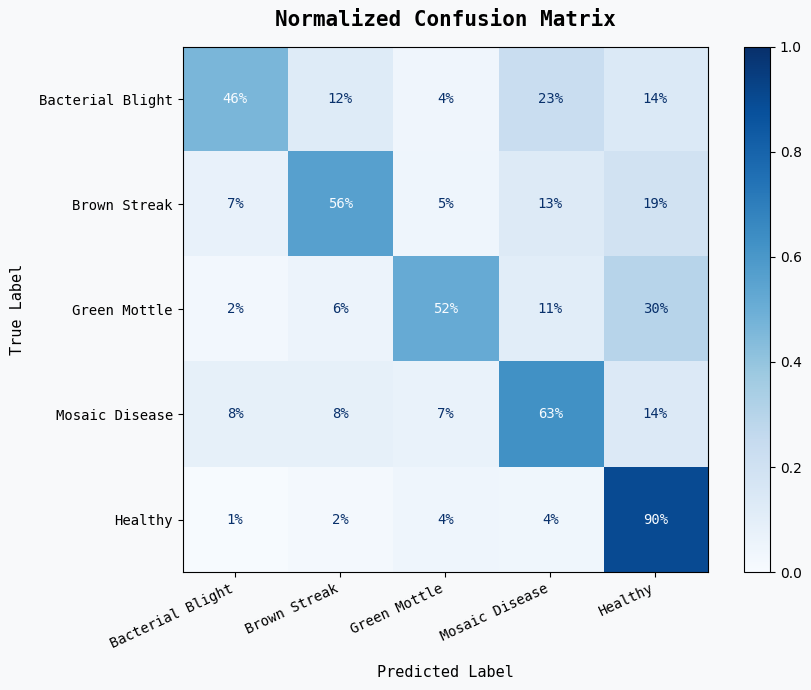

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

short_names = [
    "Bacterial Blight",
    "Brown Streak",
    "Green Mottle",
    "Mosaic Disease",
    "Healthy"
]

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels, normalize='true')

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=short_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.colorbar(disp.im_, ax=ax)
# Fix the color scale after plotting
disp.im_.set_clim(0, 1)


# Style the numbers as percentages
for text in disp.text_.ravel():
    text.set_text(f"{float(text.get_text()):.0%}")
    text.set_fontsize(10)
    text.set_fontfamily('monospace')

plt.xticks(rotation=25, ha='right', fontsize=10, fontfamily='monospace')
plt.yticks(fontsize=10, fontfamily='monospace')
ax.set_title('Normalized Confusion Matrix', fontsize=15,
             fontfamily='monospace', fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11, fontfamily='monospace', labelpad=10)
ax.set_ylabel('True Label', fontsize=11, fontfamily='monospace', labelpad=10)

plt.tight_layout()
plt.savefig('normalized_cm.png', dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA', edgecolor='none')
plt.show()

In [18]:
from google.colab import files
files.download('normalized_cm.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Try these one by one to find your class mapping:
print(class_names)        # your list — what order is it in?
print(num_classes)

# If you used tf.keras.utils.image_dataset_from_directory, the order is alphabetical
# So the indices would be:
for i, name in enumerate(sorted(class_names)):
    print(f"  {i}: {name}")

['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']
5
  0: Cassava___bacterial_blight
  1: Cassava___brown_streak_disease
  2: Cassava___green_mottle
  3: Cassava___healthy
  4: Cassava___mosaic_disease
